In [9]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import TextLoader

loader = TextLoader("research_notes.txt", encoding="utf-8")
doc = loader.load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(doc)
vectorstore = FAISS.from_documents(
    chunks,
    HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
)
retriever = vectorstore.as_retriever()
print(f"Indexed {len(chunks)} chunks")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6891.26it/s]


Indexed 7 chunks


In [10]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="groq:openai/gpt-oss-120b")
print("LLM ready")

LLM ready


In [11]:
from pydantic import BaseModel
from langchain_core.documents import Document
from typing import List

# -------------------------
# 2. State Definition
# -------------------------
class RAGReflectionState(BaseModel):
    question: str
    retrieved_docs: List[Document] = []
    answer: str = ""
    reflection: str = ""
    revised: bool = False
    attempts: int = 0

In [12]:
def retrive_doc(state:RAGReflectionState)->RAGReflectionState:
    docs = retriever.invoke(state.question)
    return state.model_copy(update={"retrieved_docs": docs})

# b. Generate Answer
def generate_answer(state: RAGReflectionState) -> RAGReflectionState:
    
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
Use the following context to answer the question:

Context:
{context}

Question:
{state.question}
"""
    answer = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": answer, "attempts": state.attempts + 1})

In [13]:
# c. Self-Reflect
def reflect_on_answer(state: RAGReflectionState) -> RAGReflectionState:
    
    prompt = f"""
Reflect on the following answer to see if it fully addresses the question. 
State YES if it is complete and correct, or NO with an explanation.

Question: {state.question}

Answer: {state.answer}

Respond like:
Reflection: YES or NO
Explanation: ...
"""
    result = llm.invoke(prompt).content
    is_ok = "reflection: yes" in result.lower()
    return state.model_copy(update={"reflection": result, "revised": not is_ok})

In [14]:
# d. Finalizer
def finalize(state: RAGReflectionState) -> RAGReflectionState:
    return state

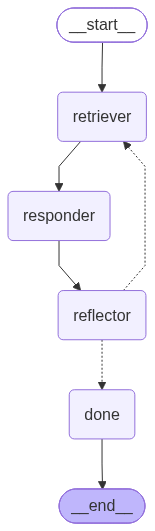

In [15]:
from langgraph.constants import END
from langgraph.graph import StateGraph

# -------------------------
# 4. LangGraph DAG
# -------------------------
def should_revise(state: RAGReflectionState) -> str:
    """Route: retry retrieval if answer needs revision and attempts < 2, else finalize."""
    if state.revised and state.attempts < 2:
        return "retriever"
    return "done"

builder = StateGraph(RAGReflectionState)
builder.add_node("retriever", retrive_doc)
builder.add_node("responder", generate_answer)
builder.add_node("reflector", reflect_on_answer)
builder.add_node("done",      finalize)

builder.set_entry_point("retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", "reflector")
builder.add_conditional_edges(
    "reflector",
    should_revise,
    {"retriever": "retriever", "done": "done"}
)
builder.add_edge("done", END)

graph = builder.compile()
graph

In [16]:
query = "What were the challenges faced during Reformer training and how were they resolved?"
initial_state = RAGReflectionState(question=query)
final = graph.invoke(initial_state)

print("\n📄 Answer:\n",        final["answer"])
print("\n🪞 Reflection:\n",    final["reflection"])
print("\n🔁 Attempts made:",    final["attempts"])
print("\n✅ Revised needed:",   final["revised"])


📄 Answer:
 **Challenges during Reformer training**

| Issue | Why it mattered |
|------|-----------------|
| **Bucket collisions** | The locality‑sensitive hashing (LSH) attention groups tokens into buckets; when many tokens fall into the same bucket the attention matrix becomes dense, blowing up memory and hurting the intended efficiency. |
| **Inconsistent loss spikes after ~5 k steps** | After a few thousand updates the training loss would suddenly jump, indicating instability in the optimizer dynamics (often triggered by the stochastic nature of LSH and the very sparse gradients). |
| **Sparse gradient updates in LSH attention** | Because only a few token pairs receive non‑zero attention weights, the back‑propagated gradients are extremely sparse, leading to noisy updates and slower convergence. |

**How the problems were addressed**

| Solution | What it tackled |
|----------|-----------------|
| **Gradient clipping** | Capped the magnitude of gradients, preventing the occasional